In [1]:
import matplotlib.pyplot as plt
import dask.array as da
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd

In [2]:
df = pd.read_csv("/yoren62/users/hannahbolen/immunofluorescence/slidescan_20250723_o8_gH2AX/counts.csv")
df

,file,count
0,o8n_day3_s13.ome.tif,44327
1,o8n_day3_s21.ome.tif,37325
2,o8p_day3_s13.ome.tif,31436
3,o8p_day3_s21.ome.tif,15713
4,o8p_day0_s13.ome.tif,14626
5,o8p_day0_s21.ome.tif,12529
6,o8n_day0_s13.ome.tif,12380
7,o8n_day0_s21.ome.tif,12003
8,o8p_day7_s13.ome.tif,6507
9,o8n_1gray_s21.ome.tif,6179


In [33]:
img_root = "/yoren62/users/hannahbolen/immunofluorescence/slidescan_20250723_o8_gH2AX/20251112/"
img_name = "o8n_day3_s13.ome.tif"
img_path = "".join([img_root, img_name])
img = tifffile.imread(img_path, aszarr=True)
img = da.from_zarr(img)
gfp_intensity = (256, 6912)
gfp_intensity_drama = (256, 5000)
cy5_intensity = (256, 4864)
type = "16bit"
nuclei = img[0]
cy5 = img[1]
nuclei_rescale = ski.exposure.rescale_intensity(nuclei, in_range = gfp_intensity)
cy5_rescale = ski.exposure.rescale_intensity(cy5, in_range = cy5_intensity)


In [ ]:
#hist, centers = ski.exposure.histogram(nuclei[::500,::500])
#axes.plot(centers, hist)
# fig, ax = ski.filters.try_all_threshold(nuclei[::1000,::1000], figsize = (8, 8), verbose=True) ## try otsu and mean


ds = 10
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
fig.tight_layout()

nuclei_ds = nuclei[::ds,::ds].compute()

thresholdOtsu = ski.filters.threshold_otsu(nuclei_ds)
nuclei_otsu = nuclei_ds>=thresholdOtsu

ax[0].imshow(ski.exposure.rescale_intensity(nuclei_ds, in_range=gfp_intensity_drama), cmap="gray")
ax[0].set_title("original")
ax[0].set_axis_off()


ax[1].imshow(nuclei_otsu, cmap="gray")
ax[1].set_title("Otsu")
ax[1].set_axis_off()

plt.show()

In [ ]:
mask_nuclei = (nuclei >= thresholdOtsu).compute()
lbl_nuclei = label(mask_nuclei, connectivity=2)
mask_file = "".join([img_path.split(".")[0], "_mask.tif"])
img_dtype = tifffile.TiffFile(img_path).pages[0].dtype
tifffile.imwrite(mask_file, mask_nuclei.astype(img_dtype))

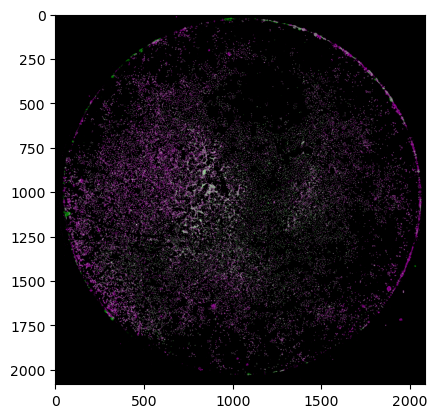

In [ ]:
ds = 10
mask_file = "".join([img_path.split(".")[0], "_mask.tif"])
masked = tifffile.imread(mask_file, aszarr=True)
masked = da.from_zarr(masked)

nuclei_rescale8 = nuclei_rescale.astype('uint8')
cy5_rescale8 = cy5_rescale.astype('uint8')
cy5_8 = cy5.astype('uint8')
masked8 = masked.astype('uint8')

colorized = da.stack([cy5_rescale8, nuclei_rescale8, cy5_rescale8],axis = -1)
#plt.imshow(colorized[,::ds,::ds])

plt.imshow(colorized[::ds,::ds,:])

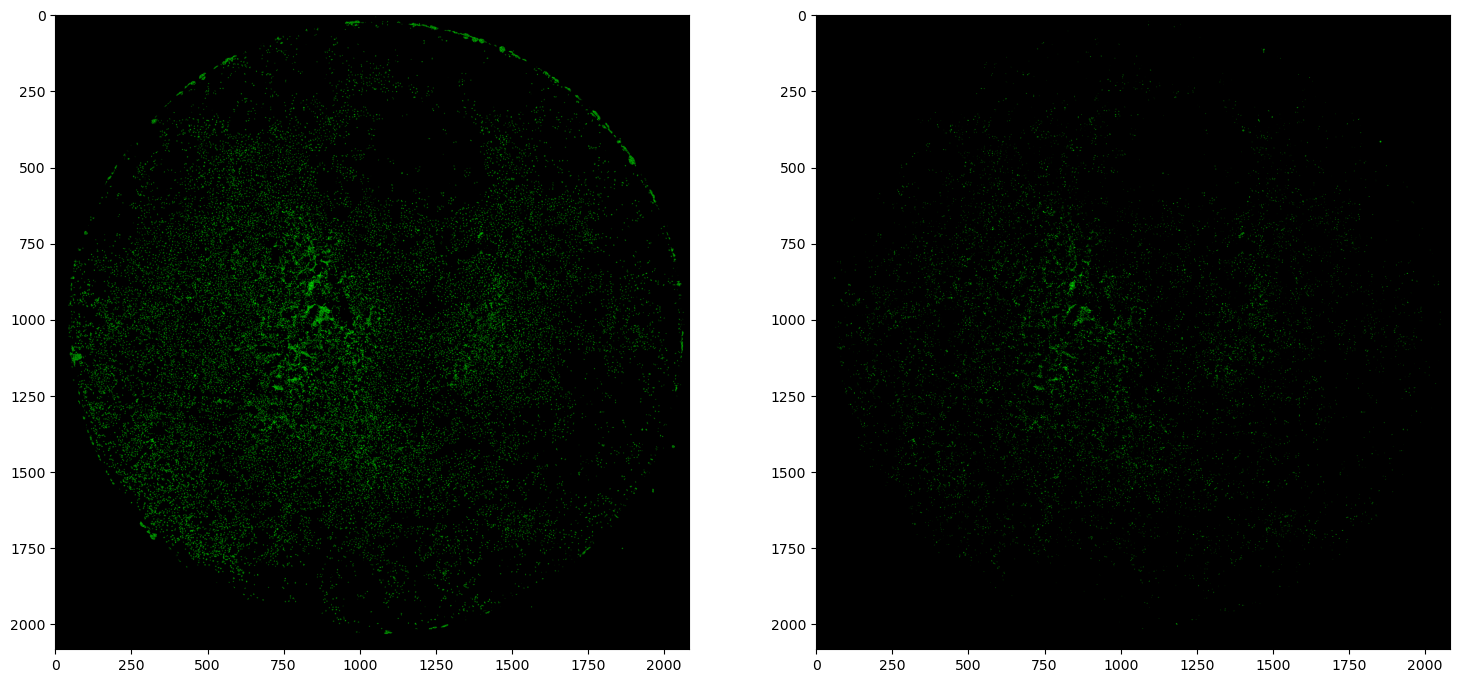

In [34]:
ds = 10
masked = tifffile.imread(mask_file, aszarr=True)
masked = da.from_zarr(masked)

masked8 = masked.astype('uint8')[::ds,::ds]

nuclei_masked = nuclei_rescale*masked

fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))

green = ski.color.gray2rgb(nuclei_rescale)*[0,1,0]
green8 = green.astype('uint8')[::ds,::ds]
ax[0].imshow(green.astype('uint8')[::ds,::ds])

green_masked = ski.color.gray2rgb(nuclei_masked)*[0,1,0]
ax[1].imshow(green_masked.astype('uint8')[::ds,::ds])

plt.show()

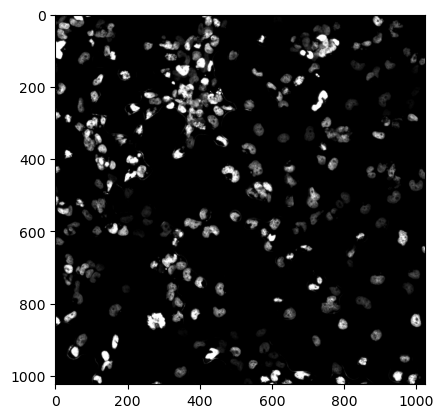

In [23]:
H, W = nuclei_rescale.shape
h, w = 1024, 1024

y0 = H//2 - h//2
x0 = W//2 - w//2

region = nuclei_rescale[y0:y0+h, x0:x0+w]
plt.imshow(region.compute(), cmap="gray")

# # pick any chunk index by coordinates
# y_start = 2000
# x_start = 2000
# size = 2048

# patch = nuclei_rescale[y_start:y_start+size, x_start:x_start+size]
# plt.imshow(patch.compute(), cmap="gray")
# plt.show()

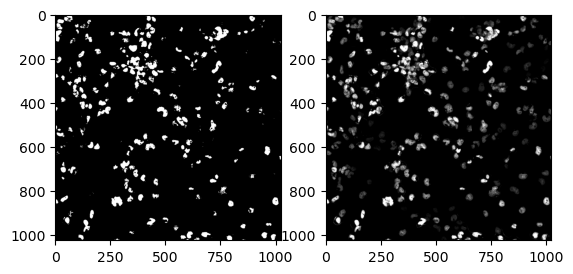

In [ ]:
## assess thresholding -- center region

mask_nuclei = da.from_zarr(tifffile.imread(mask_file, aszarr=True))

H, W = nuclei_rescale.shape
h, w = 1024, 1024

y0 = H//2 - h//2
x0 = W//2 - w//2
fig, ax = plt.subplots(ncols=2)
ax[0].imshow(mask_nuclei[y0:y0+h, x0:x0+w], cmap="gray")
ax[1].imshow(nuclei_rescale[y0:y0+h, x0:x0+w], cmap="gray")
plt.show()